In [ ]:
!pip uninstall -y keratorch

Found existing installation: keratorch 0.0.1
Uninstalling keratorch-0.0.1:
  Successfully uninstalled keratorch-0.0.1


In [1]:
!pip install git+https://github.com/JamorMoussa/keratorch.git

  Cloning https://github.com/JamorMoussa/keratorch.git to /tmp/pip-req-build-d42z51xy
  Running command git clone --filter=blob:none --quiet https://github.com/JamorMoussa/keratorch.git /tmp/pip-req-build-d42z51xy
  Resolved https://github.com/JamorMoussa/keratorch.git to commit 4164730179681f56d6e5edd1858a49b90409461b
  Preparing metadata (setup.py) ... done
  Created wheel for keratorch: filename=keratorch-0.0.1-py3-none-any.whl size=12241 sha256=acfb9f40ad900c4686aa575272467254b504217d4d3c968d7fa604531e300359
  Stored in directory: /tmp/pip-ephem-wheel-cache-ggiqfxkm/wheels/92/7f/94/34475bcf38ef6f5980da5eb3ce78ff6ebdd8aebb2d30325b80
Successfully built keratorch


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms


import keratorch as kt

In [57]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 128

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


In [58]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# # get some random training images
# dataiter = iter(trainloader)
# images, labels = next(dataiter)

# # show images
# imshow(torchvision.utils.make_grid(images))
# # print labels
# print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [59]:
# class Net(kt.nn.ktModule):
#     def __init__(self):
#         super().__init__()
#         self.conv1 = nn.Conv2d(3, 6, 5)
#         self.pool = nn.MaxPool2d(2, 2)
#         self.conv2 = nn.Conv2d(6, 16, 5)
#         self.fc1 = nn.Linear(16 * 5 * 5, 120)
#         self.fc2 = nn.Linear(120, 84)
#         self.fc3 = nn.Linear(84, 10)

#     def forward(self, x):
#         x = self.pool(F.relu(self.conv1(x)))
#         x = self.pool(F.relu(self.conv2(x)))
#         x = torch.flatten(x, 1) # flatten all dimensions except batch
#         x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
#         x = self.fc3(x)
#         return x

In [60]:
# net = Net()

In [61]:
def log(x):
  print(x.shape)
  return x

In [62]:
net = kt.nn.ktSequential(
            nn.Conv2d(3, 6, 3),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(6, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 128),
            nn.ReLU(),
            nn.Linear(128, 84),
            nn.ReLU(),
            nn.Linear(84, 32),
            nn.ReLU(),
            nn.Linear(32, 10)
        )

In [63]:
net

ktSequential(
  (0): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(6, 32, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=1152, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=84, bias=True)
  (10): ReLU()
  (11): Linear(in_features=84, out_features=32, bias=True)
  (12): ReLU()
  (13): Linear(in_features=32, out_features=10, bias=True)
)

In [64]:
@torch.no_grad()
def accuracy(state: kt.state.ktState):

    outs = state.train.model_output.outputs.argmax(dim=-1)
    targets = state.train.batch[1]

    return (outs == targets).sum()/len(targets)

In [65]:
criterion = nn.CrossEntropyLoss()
optimizer = kt.optim.Adam(lr=0.001)

In [66]:
class Trainer(kt.train.ktTrainer):

  def __init__(self):
      super(Trainer, self).__init__()

  def move_to_device(self, batch: tuple[torch.Tensor]):
      return [
          batch[0].to(self.state.device),
          batch[1].to(self.state.device),
      ]

In [67]:
trainer = Trainer()

In [68]:
trainer.compile(
    model= net,
    loss_fn= criterion,
    optimizer= optimizer,
    device= torch.device("cuda"),
    metrics= [
        kt.metrics.Metric(name="acc", metric_func= accuracy)
    ],
)

In [69]:
hist = trainer.train(trainloader=trainloader, epochs=10, num_records=100)


Epoch: [0/10]


acc: 0.48750: 100%|██████████| 391/391 [00:19<00:00, 19.79it/s]



Epoch: [1/10]


acc: 0.52344: 100%|██████████| 391/391 [00:17<00:00, 22.03it/s]



Epoch: [2/10]


...

acc: 0.61719: 100%|██████████| 391/391 [00:16<00:00, 23.07it/s]



Epoch: [8/10]


acc: 0.67188: 100%|██████████| 391/391 [00:18<00:00, 21.51it/s]



Epoch: [9/10]


acc: 0.70312: 100%|██████████| 391/391 [00:16<00:00, 23.19it/s]


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

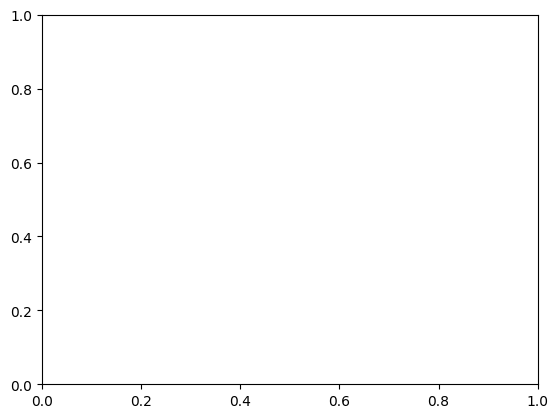

In [70]:
plt.plot(hist.history["acc"])